In [7]:
import os,sys,math,time,io,argparse,json,traceback,collections
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torchvision import transforms, utils, models, ops
import torchmetrics
from torch.utils.tensorboard import SummaryWriter
from multiprocessing import cpu_count, Pool
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm
import seaborn as sns
from datetime import datetime
from arrhytmia_data import Arrhythmia_Dataset

In [8]:
import multiprocessing
multiprocessing.set_start_method("spawn", force=True)

In [5]:
class Arrhythmia_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.inp_layer = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.batch_norm1= nn.BatchNorm1d(32)

        self.hid_layer1 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.relu2= nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.batch_norm2 = nn.BatchNorm1d(64)


        self.hid_layer2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.relu3= nn.ReLU()
        self.pool3 = nn.MaxPool1d(kernel_size=2)
        self.batch_norm3 = nn.BatchNorm1d(128)

        # input length expected after convs: 12
        self.out_layer = nn.Linear(128 * 23, 1)



    def forward(self, x):
        
        x = self.batch_norm1(self.pool1(self.relu1(self.inp_layer(x))))

        x = self.batch_norm2(self.pool2(self.relu2(self.hid_layer1(x))))
        
        x = self.batch_norm3(self.pool3(self.relu3(self.hid_layer2(x))))
        
        #return x

        x = x.reshape(x.shape[0],-1 )
        x = self.out_layer(x)

        x = torch.sigmoid(x)
        return x
        
    

Output shape debugging

In [9]:
inp = torch.rand(10, 1, 187)
net = Arrhythmia_CNN()
out = net(inp)
print(out.shape)

torch.Size([10, 128, 23])


Data Loading

In [6]:
# datasets

train_dataset = Arrhythmia_Dataset('../dataset/arrhythmia_dataset/train.csv')
val_dataset   = Arrhythmia_Dataset('../dataset/arrhythmia_dataset/val.csv')
test_dataset  = Arrhythmia_Dataset('../dataset/arrhythmia_dataset/test.csv')

# dataloaders

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    drop_last=True,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
    )

val_dataloader= torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    drop_last=False,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
    )

test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    drop_last=False,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
    )

Model Validation Function

In [9]:
def validate(net, dl, loss_fun, device):
    tm_acc = torchmetrics.classification.BinaryAccuracy().to(device)
    tm_con = torchmetrics.classification.BinaryConfusionMatrix().to(device)

    net.eval()

    total_val_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for inp, gt in dl:
            inp = inp.to(device).float()
            gt = gt.to(device).float().view(-1)

            logits = net(inp).view(-1)
            loss = loss_fun(logits, gt)

            total_val_loss += loss.item()
            n_batches += 1

            tm_acc.update(logits, gt.int())
            tm_con.update(logits, gt.int())

    acc = tm_acc.compute()
    con = tm_con.compute()
    avg_val_loss = total_val_loss / n_batches

    net.train()
    return avg_val_loss, acc, con

Training and Validating The Model

Epoch 100/100: 100%|███ 100/100 , acc=97.32%, train_loss=0.0005, val_loss=0.1649


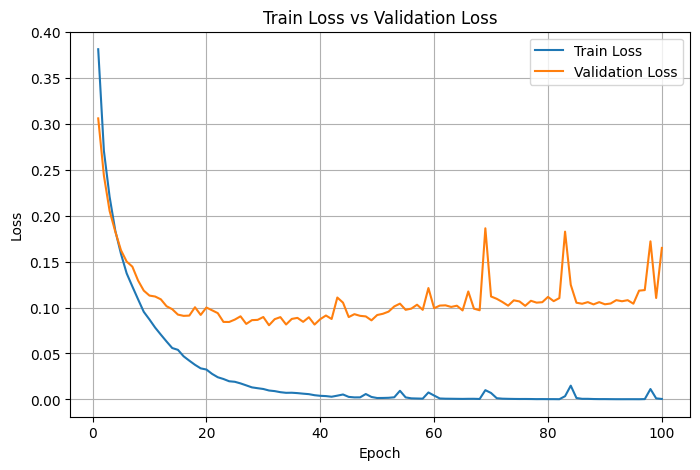

In [8]:
if __name__ == '__main__':

    learning_rate = 1e-4
    num_epochs = 100

    now = datetime.now()
    experiment_name = 'heartbeat' + now.strftime("%Y_%m_%d__%H_%M_%S")

    experiments_dir = '../ML_Models/logs'
    os.makedirs(os.path.join(experiments_dir, experiment_name), exist_ok=True)

    # model
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
    model = Arrhythmia_CNN().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fun = nn.BCELoss()

    writer = SummaryWriter(os.path.join(experiments_dir, experiment_name))

    num_iter = 0
    best_acc = 0.0

    train_losses = []
    val_losses = []

    # epoch progress bar
    epoch_bar = tqdm(
    range(num_epochs),
    bar_format="{l_bar}{bar} {n_fmt}/{total_fmt} {postfix}",
    dynamic_ncols=True
    )


    # training loop
    for cur_epoch in epoch_bar:
        epoch_bar.set_description(f"Epoch {cur_epoch+1}/{num_epochs}")
        model.train()

        running_train_loss = 0.0
        train_batches = 0

        for inp, gt in train_dataloader:
            inp = inp.to(device).float()
            gt = gt.to(device).float().view(-1)

            optimizer.zero_grad()

            logits = model(inp).view(-1)
            loss = loss_fun(logits, gt)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            train_batches += 1

            writer.add_scalar("batch_train_loss", loss.item(), num_iter)
            num_iter += 1

        avg_train_loss = running_train_loss / train_batches
        train_losses.append(avg_train_loss)

        # validate after each epoch
        avg_val_loss, acc, cf = validate(model, val_dataloader, loss_fun, device=device)
        val_losses.append(avg_val_loss)

        # tensorboard logs
        writer.add_scalar("epoch_train_loss", avg_train_loss, cur_epoch)
        writer.add_scalar("epoch_val_loss", avg_val_loss, cur_epoch)
        writer.add_scalar("val_acc", acc.item(), cur_epoch)

        # update tqdm line
        epoch_bar.set_postfix(
            train_loss=f"{avg_train_loss:.4f}",
            val_loss=f"{avg_val_loss:.4f}",
            acc=f"{acc.item()*100:.2f}%"
        )

        

        # save best
        if acc.item() > best_acc:
            best_acc = acc.item()
            torch.save(
                {
                    'net': model.state_dict(),
                    'opt': optimizer.state_dict(),
                    'epoch': cur_epoch,
                    'acc': acc.item()
                },
                os.path.join(experiments_dir, experiment_name, 'best.pth')
            )

        # save last
        torch.save(
            {
                'net': model.state_dict(),
                'opt': optimizer.state_dict(),
                'epoch': cur_epoch,
                'acc': acc.item()
            },
            os.path.join(experiments_dir, experiment_name, 'last.pth')
        )

    writer.close()

    # plot train loss vs val loss
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train Loss vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # save plot
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train Loss vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(experiments_dir, experiment_name, 'loss_curve.png'))
    plt.close()

In [5]:
%load_ext tensorboard
%reload_ext tensorboard
%tensorboard --logdir ../ML_Models


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 10238), started 0:00:35 ago. (Use '!kill 10238' to kill it.)